# Figure 6

In [1]:
import os
import sys

# Path to project root (works both in .py and .ipynb)
def get_project_root(levels_up=2):
    try:
        here = os.path.dirname(__file__)
    except NameError:
        here = os.getcwd()
    return os.path.abspath(os.path.join(here, *([".."] * levels_up)))

root_dir = get_project_root(2)
src_dir = os.path.join(root_dir, "src")

# Add src folder (parent of PyGhostID) to Python path
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

# Add paper folder
paper_dir = os.path.join(root_dir, "paper")
sys.path.insert(0, paper_dir)

# Import core as part of PyGhostID package
from PyGhostID import core as gid
print(gid.__file__)
import utils_paper as fun
print(fun.__file__)
import models_paper as mod

# other imports
import numpy as np
from scipy.integrate import solve_ivp
import jax
import jax.numpy as jnp
from jax.nn import sigmoid
from jax import jacfwd

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.pylab as pylab


pylab.rcParams.update(fun.get_rcparams())
plt.rcParams.update({'font.family':'Arial'})

inCm = 1/2.54 # convert inch to cm for plotting


w:\GitHub\GhostID\src\PyGhostID\core.py
w:\GitHub\GhostID\paper\utils_paper.py


## Figure 6a-d
Ghost plane in coupled theta neuron model from Augustsson & Martens 2024 (https://doi.org/10.1063/5.0226338)

**Figure 6a**

GhostID: Trajectory does not leave U_eps - stopping ghostID.
Number of ghosts identified: 0


GhostID: Trajectory does not leave U_eps - stopping ghostID.
Number of ghosts identified: 0


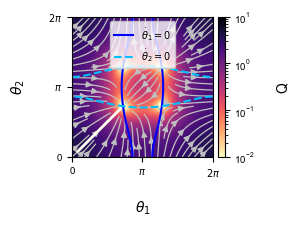

In [2]:
######################
# Before bifurcation #
######################

# set parameters
n = -0.25; K = 0.1; pS = np.pi
parameters_theta =  [n,K,pS]

# simulate trajectory 
dt = 0.005
timesteps = np.linspace(0,30,int(30/dt))
sol = solve_ivp(mod.coupledThetaNeurons, (0, 30), [0.25,0.25],
                    t_eval=timesteps, args=(parameters_theta,),method='RK45',rtol=1e-4,atol=1e-6)

# run ghostID
Trj=sol.y.T
ghostSeq, ctrlPlots = gid.ghostID(mod.coupledThetaNeurons,parameters_theta,dt,Trj,peak_kwargs={"prominence":0,"width":50},ctrlOutputs={"ctrl_qplot":True,"qplot_xscale":"linear","ctrl_evplot":True,"return_ctrl_figs":True}) #
print("Number of ghosts identified:",len(ghostSeq))


#  plot phase space
xmin=0;xmax=2*np.pi
ymin=0;ymax=2*np.pi

Ng=100
x_range=np.linspace(xmin,xmax,Ng)
y_range=np.linspace(ymin,ymax,Ng)
grid_ss = np.meshgrid(x_range, y_range)
Xg,Yg=grid_ss

Q, coords = gid.qOnGrid(mod.coupledThetaNeurons,parameters_theta,coords=[x_range,y_range], jit=True)

plt.figure(figsize=(5*inCm,7*inCm))
ax = plt.gca()

def flow_model(t,z): 
        return mod.coupledThetaNeurons(t,z,parameters_theta)
U,V=fun.vector_field(flow_model,(Xg, Yg),dim='2D') 

ax.streamplot(
    Xg, Yg,
    U, V,
    density=0.8,
    color=[0.75, 0.75, 0.75, 1],
    arrowsize=0.9,
    linewidth=0.9)

# plot trajectory
ax.plot(sol.y[0],sol.y[1],'-',color='ivory',lw=2)

# plot Q-value
vmin = 1e-2 # Define log scale range 
vmax = 10 # Avoid zero or negative values 
im = ax.imshow(Q.T, extent=(x_range.min(), x_range.max(), y_range.min(), y_range.max()), origin='lower', cmap='magma_r', norm=LogNorm(vmin=vmin, vmax=vmax)) 

# nullclines
f1,f2 = mod.coupledThetaNeurons(0,jnp.array([Xg,Yg]),parameters_theta)
ax.contour(Xg, Yg, f1, levels=[0], colors='blue', linewidths=1.5, linestyles='-')
ax.contour(Xg, Yg, f2, levels=[0], colors='deepskyblue', linewidths=1.5, linestyles='--')
ax.plot([], [], color='blue', lw=1.5, linestyle='-', label=r'$\dot\theta_1 = 0$')
ax.plot([], [], color='deepskyblue', lw=1.5, linestyle='--', label=r'$\dot\theta_2 = 0$')

# add colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(im, cax=cax,label="Q")

#labels, limits, legend
ax.set_xlabel(r"$\theta_1$")
ax.set_ylabel(r"$\theta_2$")
ax.set_xlim(xmin,xmax); ax.set_xticks([0,np.pi,2*np.pi]); ax.set_xticklabels(['0',r'$\pi$',r'$2\pi$'])
ax.set_ylim(ymin,ymax); ax.set_yticks([0,np.pi,2*np.pi]); ax.set_yticklabels(['0',r'$\pi$',r'$2\pi$'])
ax.legend(fontsize=7)
plt.savefig("Figure6.svg")
plt.show()


**Figure 6b**

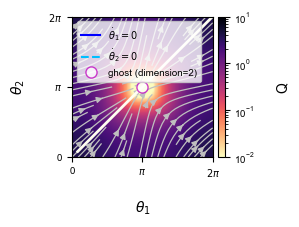

In [5]:
######################
# After bifurcation #
######################

# set parameters
n = 0.01; K = 0.1; pS = np.pi
parameters_theta =  [n,K,pS]

# simulate trajectory 
dt = 0.005
timesteps = np.linspace(0,30,int(30/dt))
sol = solve_ivp(mod.coupledThetaNeurons, (0, 30), [0.25,0.25],
                    t_eval=timesteps, args=(parameters_theta,),method='RK45',rtol=1e-4,atol=1e-6)

# run ghostID
Trj=sol.y.T
ghostSeq, ctrlPlots = gid.ghostID(mod.coupledThetaNeurons,parameters_theta,dt,Trj,peak_kwargs={"prominence":0,"width":50},ctrlOutputs={"ctrl_qplot":True,"qplot_xscale":"linear","ctrl_evplot":True,"return_ctrl_figs":True}) #

#  plot phase space
xmin=0;xmax=2*np.pi
ymin=0;ymax=2*np.pi

Ng=100
x_range=np.linspace(xmin,xmax,Ng)
y_range=np.linspace(ymin,ymax,Ng)
grid_ss = np.meshgrid(x_range, y_range)
Xg,Yg=grid_ss

Q, coords = gid.qOnGrid(mod.coupledThetaNeurons,parameters_theta,coords=[x_range,y_range], jit=True)

plt.figure(figsize=(5*inCm,7*inCm))
ax = plt.gca()

def flow_model(t,z): 
        return mod.coupledThetaNeurons(t,z,parameters_theta)
U,V=fun.vector_field(flow_model,(Xg, Yg),dim='2D') 

ax.streamplot(
    Xg, Yg,
    U, V,
    density=0.8,
    color=[0.75, 0.75, 0.75, 1],
    arrowsize=0.9,
    linewidth=0.9)

# plot trajectory
ax.plot(sol.y[0],sol.y[1],'-',color='ivory',lw=2)

# plot Q-value
vmin = 1e-2 # Define log scale range 
vmax = 10 # Avoid zero or negative values 
im = ax.imshow(Q.T, extent=(x_range.min(), x_range.max(), y_range.min(), y_range.max()), origin='lower', cmap='magma_r', norm=LogNorm(vmin=vmin, vmax=vmax)) 

# nullclines
f1,f2 = mod.coupledThetaNeurons(0,jnp.array([Xg,Yg]),parameters_theta)
ax.contour(Xg, Yg, f1, levels=[0], colors='blue', linewidths=1.5, linestyles='-')
ax.contour(Xg, Yg, f2, levels=[0], colors='deepskyblue', linewidths=1.5, linestyles='--')
ax.plot([], [], color='blue', lw=1.5, linestyle='-', label=r'$\dot\theta_1 = 0$')
ax.plot([], [], color='deepskyblue', lw=1.5, linestyle='--', label=r'$\dot\theta_2 = 0$')

# plot ghost
gx,gy = ghostSeq[0]["position"]
ax.plot(gx,gy,'ow',mec='m',markersize=8,alpha=0.75,label=f'ghost (dimension={ghostSeq[0]["dimension"]})')

# add colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(im, cax=cax,label="Q")

#labels, limits, legend
ax.set_xlabel(r"$\theta_1$")
ax.set_ylabel(r"$\theta_2$")
ax.set_xlim(xmin,xmax); ax.set_xticks([0,np.pi,2*np.pi]); ax.set_xticklabels(['0',r'$\pi$',r'$2\pi$'])
ax.set_ylim(ymin,ymax); ax.set_yticks([0,np.pi,2*np.pi]); ax.set_yticklabels(['0',r'$\pi$',r'$2\pi$'])
ax.legend(fontsize=7)
plt.savefig("Figure6b.svg")
plt.show()


Plot control outputs from ghostID (only for verification)

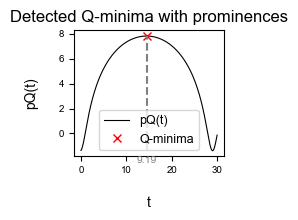

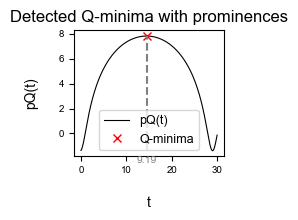

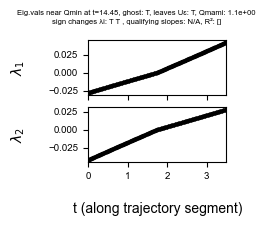

In [6]:
# pQ timeseries and Q-minima
fig, ax = ctrlPlots[0]
fig.set_size_inches(5*inCm,6*inCm)
plt.figure(fig)
plt.show()

# # eigenvalues across trajectories
fig, axes = ctrlPlots[1]
suptxt = fig._suptitle.get_text()
fig.suptitle(suptxt,fontsize=5.5)
fig.set_size_inches(5*inCm,5*inCm)
axes[0].set_xlim(0,3.5)
axes[1].set_xlim(0,3.5)
axes[0].set_ylabel('$\\lambda_1$')
axes[1].set_ylabel('$\\lambda_2$')
axes[1].set_xlabel('t (along trajectory segment)')
plt.figure(fig)
plt.show()

Track ghost in parameter space and plot in bifurcation diagram

In [7]:
ghost_start = ghostSeq[0]

positions_ghosts, paramVals, ghostSeqs =  gid.track_ghost_branch(ghostSeq[0], mod.coupledThetaNeurons, parameters_theta, 
                                                                 0, 20, 0.05, 25, dt, delta=0.35, icStep=0.2, mode="first", 
                                                                 epsilon_gid=0.2,qmin_method="BFGS",evLimit=0.15,solve_ivp_method='RK45', 
                                                                 peak_kwargs={"prominence":0},ctrlOutputs={"ctrl_qplot":False,"qplot_xscale":"linear","ctrl_evplot":False},
                                                                 rtol=1e-4,atol=1e-6,distQminThr=0.3)

Progress: 100.00% | param value=1.01000: 100%|██████████| 21/21 [00:52<00:00,  2.52s/it]


Calculating mutual information between system response and inputs

In [20]:
dt = 0.01
t_end = 1000
timesteps = np.linspace(0,t_end,int(t_end/dt))

# Generate input signals
from statsmodels.tsa.stattools import adfuller
from tqdm import tqdm

N_reps= 1
input_ts = []
for _ in tqdm(range(N_reps)):
    while True:
        t, signal = fun.generate_peak_series(
            total_duration=t_end,
            dt=dt,
            amp_mean=1,
            amp_std=0.3,
            peak_width=3,
            n=4,
            ipi_distr="exponential",
            ipi_params=[8]
        )
        result = adfuller(signal[::2], autolag='AIC')
        if result[1] <= 0.05:
            input_ts.append(signal/5)
            break

100%|██████████| 1/1 [00:04<00:00,  4.55s/it]


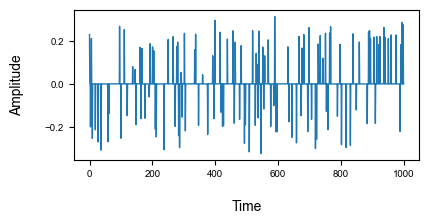

In [21]:
plt.figure(figsize=(8, 4))
for i in range(1):
    plt.subplot(2,2,1+i)
    plt.plot(t, input_ts[i],lw=1)
    plt.xlabel("Time")
    plt.ylabel("Amplitude")
plt.tight_layout()
  

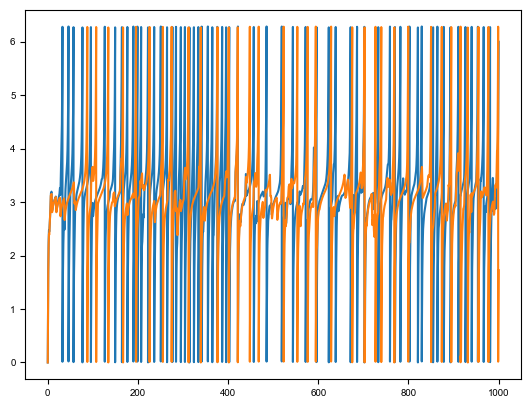

In [22]:
n = 0.01; K = 0.1; pS = np.pi
parameters_theta_na =  [n,K,pS,[t_end,dt,input_ts[0]]]
parameters_theta_single_na =  [n,pS,[t_end,dt,input_ts[0]]]

sol = solve_ivp(mod.coupledThetaNeurons_na, (0, t_end), [0,0],
                    t_eval=timesteps, args=(parameters_theta_na,),method='RK45',rtol=1e-4,atol=1e-6)

sol2 = solve_ivp(mod.singleThetaNeuron_na, (0, t_end), [0],
                    t_eval=timesteps, args=(parameters_theta_single_na,),method='RK45',rtol=1e-4,atol=1e-6)


plt.plot(sol.t,sol.y[0]%(2*np.pi))
plt.plot(sol2.t,sol2.y[0]%(2*np.pi))

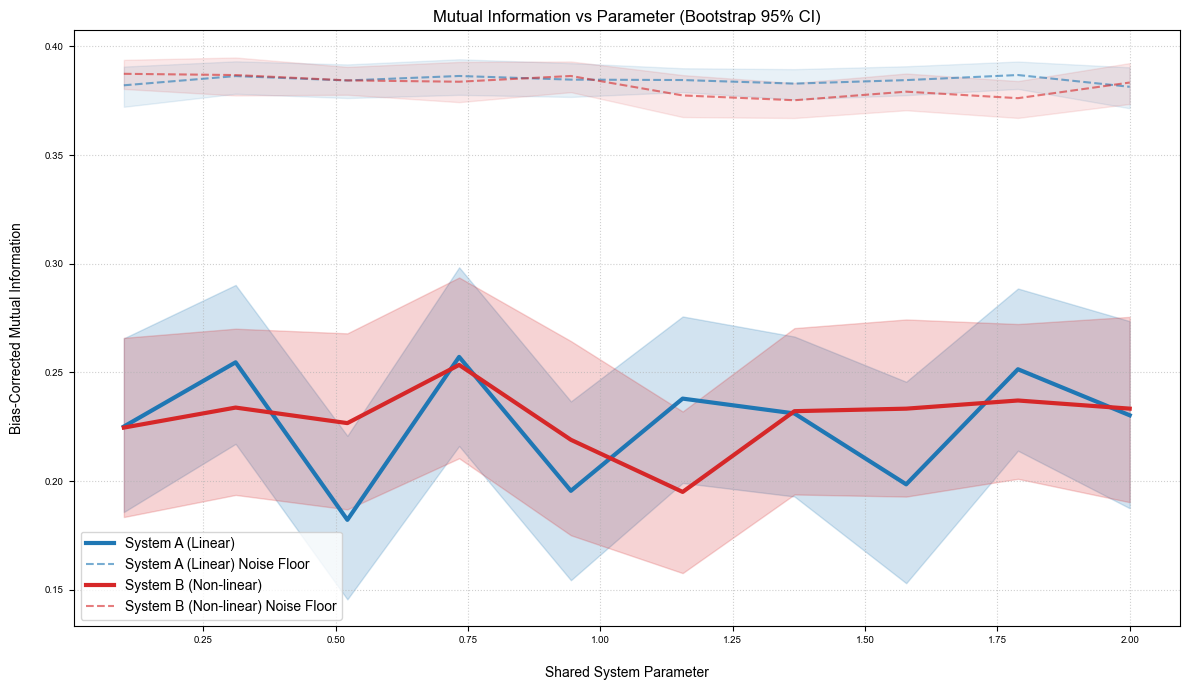

Paired comparison at parameter 1.16
Mean MI difference (A − B): 0.0429
95% bootstrap CI: [-0.0105, 0.0975]


In [ ]:
# =========================
# 1. CORE FUNCTIONS
# =========================

def get_rep_noise_floor(x, y, nbins, N, n_perms=50):
    """
    95th percentile of MI under permutation null
    (per repetition).
    """
    null_vals = []
    for _ in range(n_perms):
        y_perm = np.random.permutation(y)
        null_vals.append(calculate_mi_corrected(x, y_perm, nbins, N))
    return np.percentile(null_vals, 95)


def bootstrap_ci_mean(data, n_boot=2000):
    """
    Bootstrap CI for the mean of i.i.d. samples.
    """
    data = np.asarray(data)
    n = len(data)
    boot_means = [
        np.mean(np.random.choice(data, n, replace=True))
        for _ in range(n_boot)
    ]
    return np.mean(data), np.percentile(boot_means, [2.5, 97.5])


def bootstrap_ci_paired_difference(x, y, n_boot=5000):
    """
    Paired bootstrap CI for mean(x - y).
    """
    x = np.asarray(x)
    y = np.asarray(y)
    assert len(x) == len(y)

    diffs = x - y
    n = len(diffs)

    boot_means = [
        np.mean(diffs[np.random.randint(0, n, n)])
        for _ in range(n_boot)
    ]
    return np.mean(diffs), np.percentile(boot_means, [2.5, 97.5])


# =========================
# 2. SIMULATION
# =========================

N_reps = 30
T_len = 500
nbins = 10
params = np.linspace(0.1, 2.0, 10)
n_systems = 2
n_perms_per_rep = 20

# Storage: [system, parameter, repetition]
results_mi = np.zeros((n_systems, len(params), N_reps))
results_floor = np.zeros((n_systems, len(params), N_reps))

for p_idx, p in enumerate(params):
    for rep in range(N_reps):

        # ✔ Shared input for all systems
        input_ts = np.random.rand(T_len)

        for sys_id in range(n_systems):

            if sys_id == 0:
                response_ts = 0.5 * p * input_ts + np.random.normal(0, 0.5, T_len)
            else:
                response_ts = 0.4 * (p**1.5) * input_ts + np.random.normal(0, 0.5, T_len)

            results_mi[sys_id, p_idx, rep] = calculate_mi_corrected(
                input_ts, response_ts, nbins, T_len
            )

            results_floor[sys_id, p_idx, rep] = get_rep_noise_floor(
                input_ts, response_ts, nbins, T_len, n_perms_per_rep
            )


# =========================
# 3. PLOTTING (DESCRIPTIVE)
# =========================

plt.figure(figsize=(12, 7))
colors = ['#1f77b4', '#d62728']
labels = ['System A (Linear)', 'System B (Non-linear)']

for sys_id in range(n_systems):

    means, lows, highs = [], [], []

    for p_idx in range(len(params)):
        m, (l, h) = bootstrap_ci_mean(results_mi[sys_id, p_idx])
        means.append(m)
        lows.append(l)
        highs.append(h)

    plt.plot(params, means, color=colors[sys_id], lw=3, label=labels[sys_id])
    plt.fill_between(params, lows, highs, color=colors[sys_id], alpha=0.2)

    # --- Plot Noise Floor (Descriptive Reference Only) ---
    nf_means, nf_lows, nf_highs = [], [], []

    for p_idx in range(len(params)):
        fm, (fl, fh) = bootstrap_ci_mean(results_floor[sys_id, p_idx])
        nf_means.append(fm)
        nf_lows.append(fl)
        nf_highs.append(fh)

    plt.plot(
        params, nf_means,
        '--', color=colors[sys_id],
        alpha=0.6, lw=1.5,
        label=f"{labels[sys_id]} Noise Floor"
    )

    plt.fill_between(
        params, nf_lows, nf_highs,
        color=colors[sys_id],
        alpha=0.1
    )

plt.xlabel("Shared System Parameter")
plt.ylabel("Bias-Corrected Mutual Information")
plt.title("Mutual Information vs Parameter (Bootstrap 95% CI)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


# =========================
# 4. INFERENCE: PAIRED COMPARISON
# =========================

mid_p = len(params) // 2

delta_mean, delta_ci = bootstrap_ci_paired_difference(
    results_mi[0, mid_p],
    results_mi[1, mid_p]
)

print(f"Paired comparison at parameter {params[mid_p]:.2f}")
print(f"Mean MI difference (A − B): {delta_mean:.4f}")
print(f"95% bootstrap CI: [{delta_ci[0]:.4f}, {delta_ci[1]:.4f}]")


**Figure 6c+d**

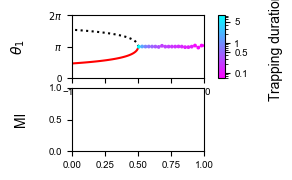

In [20]:
# load bifurcation data from XPPAUT for plotting
with open("Fig6_theta_bifurcation.dat") as f:
    lines = f.readlines()
    text = "".join(lines)

data = []

for l in lines:
    row = []
    for n in l.split(' ')[:len(l.split(' '))-1]: 
        row.append(float(n))
    data.append(np.asarray(row))

dat_theta_cpld = np.asarray(data)

from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(5*inCm,4.5*inCm))

gs = GridSpec(2, 2, figure=fig, width_ratios=[20, 1], hspace=0.15)

ax1 = fig.add_subplot(gs[0, 0])

#plot SNs from XPPAUT
id_SN = 0
id_SN_end = 61
ax1.plot(dat_theta_cpld[id_SN:id_SN_end,3],dat_theta_cpld[id_SN:id_SN_end,6],'-r')
id_us_end = 117
ax1.plot(dat_theta_cpld[id_SN_end:id_us_end,3],dat_theta_cpld[id_SN_end:id_us_end,6],':k')

trapping_durations = [ghostSeqs[i]["duration"] for i in range(len(ghostSeqs))]

ax1.plot(paramVals, positions_ghosts[:,0],'-',color='grey', lw=0.5, zorder=1)
sc = ax1.scatter(paramVals, positions_ghosts[:,0], c=trapping_durations, marker='o', s=3, norm=LogNorm(), cmap='cool_r', zorder=2)

ax1.set_ylabel(r"$\theta_1$")
ax1.set_xlabel(r"$\eta$")
ax1.set_ylim(0,2*np.pi)
ax1.set_xlim(-1,1)
ax1.set_yticks([0,np.pi,2*np.pi])
ax1.set_yticklabels(['0',r'$\pi$',r'$2\pi$']);

ax_cb = fig.add_subplot(gs[0, 1])
cb = plt.colorbar(sc, cax=ax_cb, label='Trapping duration')
cb.set_ticks([1, 0.1, 0.5, 5])
cb.set_ticklabels(['1', '0.1', '0.5', '5'])

ax2 = fig.add_subplot(gs[1, 0])
ax2.set_ylabel("MI")
plt.savefig("Figure6c+d.svg")

## Figure 6e-g
Ghost structures in tipping element model from Wunderling et al 2021 (https://esd.copernicus.org/articles/12/601/2021/)

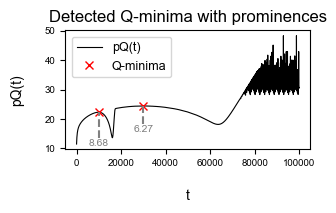

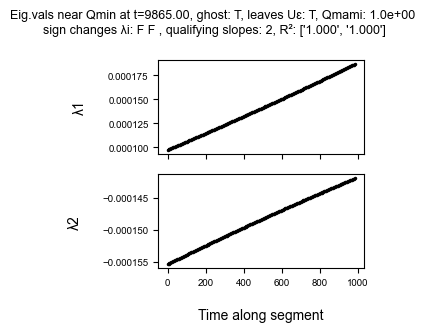

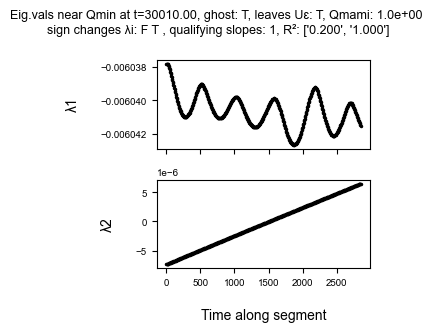

In [9]:
# Set parameters
d = 0.15
GMT = 1.51
Tcrits = np.array([1.5,1.5])
Taus = np.array([500,5000])
interactions=np.array([[0,1],
                       [1,0]])

parameters_Wunderling = [d,GMT,Tcrits,Taus,interactions]

# simulate trajectory (for testing purposes only)
dt = 5
timesteps = np.linspace(0,1e5,int(1e5/dt))
sol = solve_ivp(mod.wunderling_model, (0, 1e5), [-1.5,-1.5], 
                    t_eval=timesteps, args=(parameters_Wunderling,),method='RK45',rtol=1e-4,atol=1e-6)

Trj=sol.y.T
ghostSeqs = gid.ghostID(mod.wunderling_model,parameters_Wunderling,dt,Trj,0.01,peak_kwargs={"prominence":2,"width":50*dt},ctrlOutputs={"ctrl_qplot":True,"qplot_xscale":"linear","ctrl_evplot":True,"return_ctrl_figs":False},evLimit=0.05) #

Sample phase space to identify all ghosts in the system

In [19]:
import time
start = time.time()
result_pss = gid.ghostID_phaseSpaceSample(mod.wunderling_model,parameters_Wunderling,0,1e5,dt,
                                          [np.linspace(-1.5,1.5,100),np.linspace(-1.5,1.5,50)],n_samples=30,evLimit=0.01,
                                          peak_kwargs={"prominence":2,"width":50*dt},display_warnings=False,epsilon_gid=0.02,epsilon_SN_ghosts=0.4,epsilon_unify=0.8)
end = time.time()
print(f"Execution time for ghostID_phaseSpaceSample: {end - start} seconds")

ghostList = gid.unique_ghosts(result_pss)
print("Number of unique ghosts identified from phase space sample: ", len(ghostList))

[ghostID_phaseSpaceSample] Running with threads (11 workers)


Processing ICs: 100%|██████████| 30/30 [00:28<00:00,  1.04IC/s]

Execution time for ghostID_phaseSpaceSample: 28.945313453674316 seconds
Number of unique ghosts identified from phase space sample:  3


**Figure 6e** (timeseries)

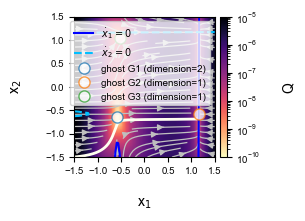

In [20]:
plt.figure(figsize=(5*inCm,4*inCm))
plt.plot(sol.t,sol.y[0],'-',lw=2)
plt.plot(sol.t,sol.y[1],'-',lw=2)
plt.xlabel('time (yrs)')
plt.ylabel('$x_i$')
plt.ylim(-1.5,1.5)
ax = plt.gca()
ax.set_xlim(-1000,1e5); ax.set_xticks([0,5e4,1e5]); ax.set_xticklabels(['0','5$\\times$10$^4$','10$^5$']);
plt.savefig("Figure6e.svg")

**Figure 6f** (phase space)

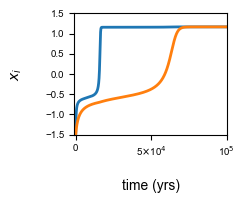

In [21]:
xmin=-1.5;xmax=1.5
ymin=-1.5;ymax=1.5

Ng=100
x_range=np.linspace(xmin,xmax,Ng)
y_range=np.linspace(ymin,ymax,Ng)
grid_ss = np.meshgrid(x_range, y_range)
Xg,Yg=grid_ss

Q, coords = gid.qOnGrid(mod.wunderling_model,parameters_Wunderling,coords=[x_range,y_range], jit=True)

plt.figure(figsize=(5*inCm,7*inCm))
ax = plt.gca()

def flow_model(t,z): 
        return mod.wunderling_model(t,z,parameters_Wunderling)
U,V=fun.vector_field(flow_model,(Xg, Yg),dim='2D') 

ax.streamplot(
    Xg, Yg,
    U, V,
    density=0.8,
    color=[0.75, 0.75, 0.75, 1],
    arrowsize=0.9,
    linewidth=0.9)

# plot trajectory
ax.plot(sol.y[0],sol.y[1],'-',color='ivory',lw=2)

# plot Q-value
vmin = 1e-10 # Define log scale range 
vmax = 1e-5 # Avoid zero or negative values 
im = ax.imshow(Q.T, extent=(x_range.min(), x_range.max(), y_range.min(), y_range.max()), origin='lower', cmap='magma_r', norm=LogNorm(vmin=vmin, vmax=vmax)) 

# nullclines
f1,f2 = mod.nullclines_Wunderling(parameters_Wunderling,(-1.5,1.5),(-1.5,1.5),Ng)
ax.contour(Xg, Yg, f1, levels=[0], colors='blue', linewidths=1.5, linestyles='-')
ax.contour(Xg, Yg, f2, levels=[0], colors='deepskyblue', linewidths=1.5, linestyles='--')
ax.plot([], [], color='blue', lw=1.5, linestyle='-', label=r'$\dot x_1 = 0$')
ax.plot([], [], color='deepskyblue', lw=1.5, linestyle='--', label=r'$\dot x_2 = 0$')

# plot ghosts
for i in range(len(ghostList)):
    gi = ghostList[i]
    gx,gy = gi["position"]
    ax.plot(gx,gy,'ow',mec=f'C{i}',markersize=8,alpha=0.75,label=f'ghost {gi["id"]} (dimension={gi["dimension"]})')

# add colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(im, cax=cax,label="Q")

#labels, limits, legend
ax.set_xlabel(r"x$_1$")
ax.set_ylabel(r"x$_2$")
ax.set_xlim(xmin,xmax); ax.set_xticks([-1.5,-1,-0.5,0,0.5,1,1.5]);
ax.set_ylim(ymin,ymax); ax.set_yticks([-1.5,-1,-0.5,0,0.5,1,1.5]);
ax.legend(fontsize=7)
plt.savefig("Figure6f.svg")
plt.show()

Identify and plot ghost connections

C:\Users\dkoch\AppData\Local\Temp\ipykernel_6160\604015036.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('cool_r')


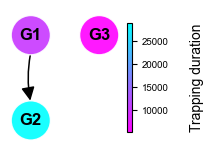

In [22]:
import matplotlib

M, M_labels = gid.ghost_connections(result_pss)

# Get trapping times
durations = [next(g['duration'] for g in ghostList if g['id'] == label) for label in M_labels]

# Normalize durations to [0, 1]
if durations:
    min_dur, max_dur = min(durations), max(durations)
    norm_durations = [(d - min_dur) / (max_dur - min_dur) for d in durations]
else:
    norm_durations = [0.0] * len(M_labels)

# Generate colors using 'cool_r' colormap
cmap = matplotlib.colormaps.get_cmap('cool_r')
nodeColors = [cmap(d) for d in norm_durations]

plt.figure(figsize=(4.5*inCm,4.5*inCm))
gid.draw_network(M, nodeColors, M_labels, layout="hierarchical",node_size=800,label_font_size=12)
plt.gca().margins(0.3)
plt.axis("off")

# Add colorbar
import matplotlib as mpl
norm = mpl.colors.Normalize(vmin=min(durations), vmax=max(durations))
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), orientation='vertical', shrink=0.8)
cbar.set_label('Trapping duration')

plt.savefig("Figure6g.svg")
plt.show()